In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X ** 2 + 1.5 * X + 2 + np.random.rand(100, 1)
len(X)

100

Text(0, 0.5, 'Y Dataset')

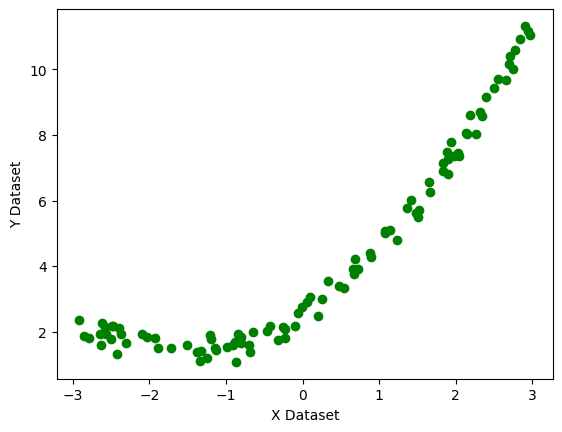

In [3]:
plt.scatter(X, y, color='g')
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
regression1 = LinearRegression()
regression1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression1.predict(X_test))
print(score)

0.8194783194974574


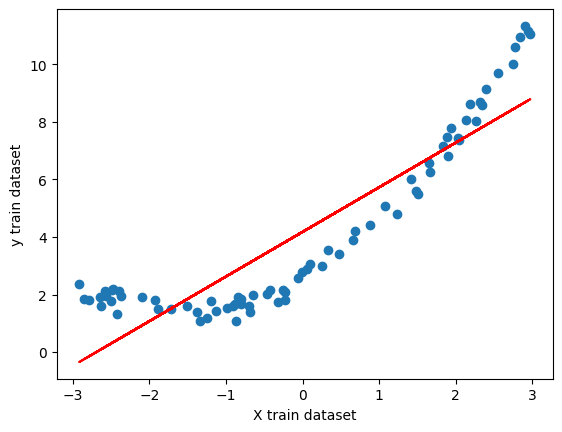

In [7]:
plt.plot( X_train, regression1.predict(X_train), color='r' )
plt.scatter(X_train, y_train)
plt.xlabel("X train dataset")
plt.ylabel("y train dataset")
plt.show()

In [8]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias = True )
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)

In [9]:
from sklearn.metrics import r2_score

score1 = r2_score(y_pred, y_test)
print(score1)

0.9949893256139649


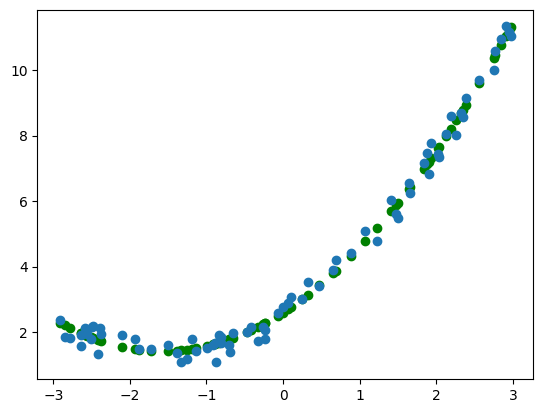

In [10]:
plt.scatter(X_train, regression.predict(X_train_poly), color='g')
plt.scatter(X_train, y_train)
plt.show()

In [11]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.fit_transform(X_new)

y_pred = regression.predict(X_test_poly)

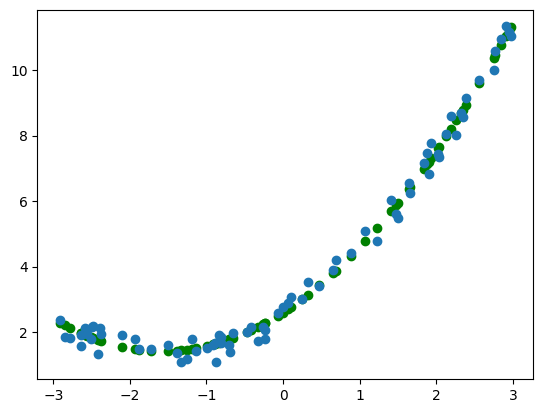

In [12]:
plt.scatter(X_train, regression.predict(X_train_poly), color='g')
plt.scatter(X_train, y_train)
plt.show()

In [13]:
from sklearn.pipeline import Pipeline

def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree= degree, include_bias=True)
    lin_regression = LinearRegression()
    poly_regression = Pipeline([
        ("Polynomial Feaures", poly_features),
        ("Linear Regression", lin_regression)
    ])
    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict( X_new )
    plt.plot(X_new, y_pred_new, 'r', linewidth = 2)
    plt.scatter(X_train, y_train, color='blue')
    plt.scatter(X_test, y_test, color='green')
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show()

C:\Users\Aayush\AppData\Local\Temp\ipykernel_26012\280863526.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


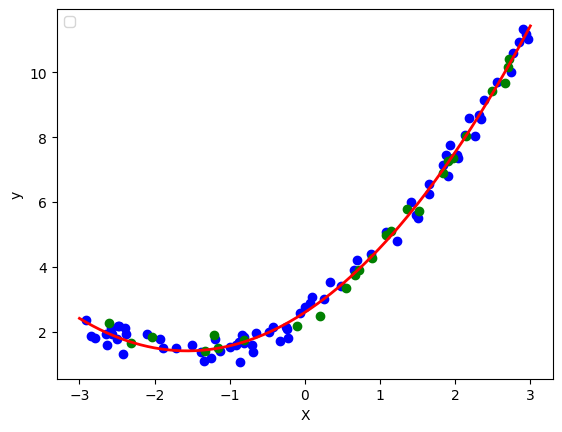

In [14]:
polynomial_regression(3)